In [1]:
import pandas as pd
import numpy as np

# Option A: Google Colab upload
# from google.colab import files
# uploaded = files.upload()
# filename = list(uploaded.keys())[0]

# Option B: Local Jupyter — set your file path directly
filename = "SpendingData.xlsx"  # or .xlsx

# Load
if filename.endswith(".xlsx"):
    df = pd.read_excel(filename)
else:
    df = pd.read_csv(filename)

df.head()


c:\Users\Gabriel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Function,Agency,Fund Type,FP Category,Fund,Subfund,Subfund Name,2026-27 Estimates,2025-26 Estimates,2024-25 Actuals,...,2003-04 Actuals,2002-03 Actuals,2001-02 Actuals,2000-01 Actuals,1999-00 Actuals,1998-99 Actuals,1997-98 Actuals,1996-97 Actuals,1995-96 Actuals,1994-95 Actuals
0,Economic Development and Government Oversight,"Agriculture and Markets, Department of",Capital Projects Funds - Other,Capital Projects,Capital Projects Fund,30000,Capital Project,9319,10319,7798,...,573.0,1545.0,1747.0,2013.0,2704.0,2494.0,4056.0,1437.0,3108.0,2912.0
1,Economic Development and Government Oversight,"Agriculture and Markets, Department of",Capital Projects Funds - Other,Assistance and Grants,Capital Projects Fund,300CC,CPF - Auth Bond,0,0,160,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Economic Development and Government Oversight,"Agriculture and Markets, Department of",Capital Projects Funds - Other,Capital Projects,Capital Projects Fund,300CC,CPF - Auth Bond,69490,53490,12245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Economic Development and Government Oversight,"Agriculture and Markets, Department of",Capital Projects Funds - Other,Assistance and Grants,Clean Water/Clean Air Implementation,305BM,CPF-1996CWA(Bon,0,0,0,...,0.0,0.0,0.0,0.0,211.0,53.0,0.0,0.0,0.0,0.0
4,Economic Development and Government Oversight,"Agriculture and Markets, Department of",Capital Projects Funds - Other,Capital Projects,Clean Water/Clean Air Implementation,305BM,CPF-1996CWA(Bon,0,0,0,...,0.0,0.0,111.0,182.0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
df.head()

,Function,Agency,Fund Type,FP Category,Fund,Subfund,Subfund Name,2026-27 Estimates,2025-26 Estimates,2024-25 Actuals,...,2003-04 Actuals,2002-03 Actuals,2001-02 Actuals,2000-01 Actuals,1999-00 Actuals,1998-99 Actuals,1997-98 Actuals,1996-97 Actuals,1995-96 Actuals,1994-95 Actuals
0,Economic Development and Government Oversight,"Agriculture and Markets, Department of",Capital Projects Funds - Other,Capital Projects,Capital Projects Fund,30000,Capital Project,9319,10319,7798,...,573.0,1545.0,1747.0,2013.0,2704.0,2494.0,4056.0,1437.0,3108.0,2912.0
1,Economic Development and Government Oversight,"Agriculture and Markets, Department of",Capital Projects Funds - Other,Assistance and Grants,Capital Projects Fund,300CC,CPF - Auth Bond,0,0,160,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Economic Development and Government Oversight,"Agriculture and Markets, Department of",Capital Projects Funds - Other,Capital Projects,Capital Projects Fund,300CC,CPF - Auth Bond,69490,53490,12245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Economic Development and Government Oversight,"Agriculture and Markets, Department of",Capital Projects Funds - Other,Assistance and Grants,Clean Water/Clean Air Implementation,305BM,CPF-1996CWA(Bon,0,0,0,...,0.0,0.0,0.0,0.0,211.0,53.0,0.0,0.0,0.0,0.0
4,Economic Development and Government Oversight,"Agriculture and Markets, Department of",Capital Projects Funds - Other,Capital Projects,Clean Water/Clean Air Implementation,305BM,CPF-1996CWA(Bon,0,0,0,...,0.0,0.0,111.0,182.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
import re

# Find year columns like "2026-27 Estimates", "2024-25 Actuals"
year_cols = [c for c in df.columns if re.match(r"\d{4}-\d{2}\s+(Estimates|Actuals)", c)]
non_year_cols = [c for c in df.columns if c not in year_cols]

# Melt to long
long_df = df.melt(
    id_vars=non_year_cols,
    value_vars=year_cols,
    var_name="year_label",
    value_name="amount"
)

# Split year and type
long_df["year_type"] = long_df["year_label"].str.extract(r"(Estimates|Actuals)")
long_df["fiscal_year"] = long_df["year_label"].str.extract(r"(\d{4}-\d{2})")
long_df["fy_start"] = long_df["fiscal_year"].str[:4].astype(int)

long_df = long_df.dropna(subset=["amount"])
long_df.head()

,Function,Agency,Fund Type,FP Category,Fund,Subfund,Subfund Name,year_label,amount,year_type,fiscal_year,fy_start
0,Economic Development and Government Oversight,"Agriculture and Markets, Department of",Capital Projects Funds - Other,Capital Projects,Capital Projects Fund,30000,Capital Project,2026-27 Estimates,9319.0,Estimates,2026-27,2026
1,Economic Development and Government Oversight,"Agriculture and Markets, Department of",Capital Projects Funds - Other,Assistance and Grants,Capital Projects Fund,300CC,CPF - Auth Bond,2026-27 Estimates,0.0,Estimates,2026-27,2026
2,Economic Development and Government Oversight,"Agriculture and Markets, Department of",Capital Projects Funds - Other,Capital Projects,Capital Projects Fund,300CC,CPF - Auth Bond,2026-27 Estimates,69490.0,Estimates,2026-27,2026
3,Economic Development and Government Oversight,"Agriculture and Markets, Department of",Capital Projects Funds - Other,Assistance and Grants,Clean Water/Clean Air Implementation,305BM,CPF-1996CWA(Bon,2026-27 Estimates,0.0,Estimates,2026-27,2026
4,Economic Development and Government Oversight,"Agriculture and Markets, Department of",Capital Projects Funds - Other,Capital Projects,Clean Water/Clean Air Implementation,305BM,CPF-1996CWA(Bon,2026-27 Estimates,0.0,Estimates,2026-27,2026


In [4]:
# Aggregate across all dimensions to get total by year/type
yearly = long_df.groupby(["fy_start", "year_type"], as_index=False)["amount"].sum()

# Pivot to columns: Actuals / Estimates
yearly_pivot = yearly.pivot(index="fy_start", columns="year_type", values="amount").reset_index()
yearly_pivot = yearly_pivot.sort_values("fy_start")

# Prefer Actuals; if missing, use Estimates
yearly_pivot["value"] = yearly_pivot["Actuals"].fillna(yearly_pivot["Estimates"])

# Variance (only when both exist)
yearly_pivot["variance"] = yearly_pivot["Actuals"] - yearly_pivot["Estimates"]
yearly_pivot["pct_variance"] = np.where(
    yearly_pivot["Estimates"] != 0,
    yearly_pivot["variance"] / yearly_pivot["Estimates"],
    np.nan
)

yearly_pivot.tail()


year_type,fy_start,Actuals,Estimates,value,variance,pct_variance
28,2022,220461057.0,NaN,220461057.0,NaN,NaN
29,2023,234867309.0,NaN,234867309.0,NaN,NaN
30,2024,241471306.0,NaN,241471306.0,NaN,NaN
31,2025,NaN,258269761.0,258269761.0,NaN,NaN
32,2026,NaN,260004189.0,260004189.0,NaN,NaN


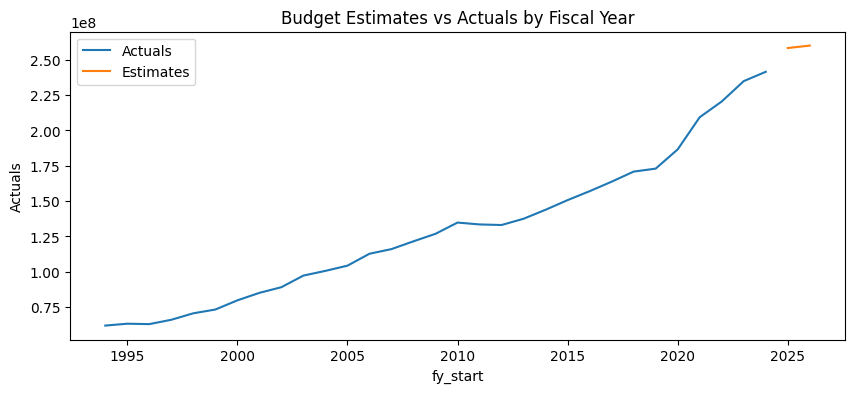

year_type,fy_start,Actuals,Estimates,variance,pct_variance
28,2022,220461057.0,NaN,NaN,NaN
29,2023,234867309.0,NaN,NaN,NaN
30,2024,241471306.0,NaN,NaN,NaN
31,2025,NaN,258269761.0,NaN,NaN
32,2026,NaN,260004189.0,NaN,NaN


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))
sns.lineplot(data=yearly_pivot, x="fy_start", y="Actuals", label="Actuals")
sns.lineplot(data=yearly_pivot, x="fy_start", y="Estimates", label="Estimates")
plt.title("Budget Estimates vs Actuals by Fiscal Year")
plt.show()

yearly_pivot[["fy_start","Actuals","Estimates","variance","pct_variance"]].tail()


In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

series = yearly_pivot.dropna(subset=["value"]).copy()

def split_ts(df, test_years=3):
    train = df.iloc[:-test_years]
    test = df.iloc[-test_years:]
    return train, test

def seasonal_naive(train, test, season=3):
    preds = []
    for i in range(len(test)):
        idx = -season + i
        preds.append(train["value"].iloc[idx] if abs(idx) <= len(train) else train["value"].iloc[-1])
    return np.array(preds)

def sarimax_forecast(train, steps, season=3):
    model = SARIMAX(train["value"], order=(1,1,1), seasonal_order=(1,1,1,season),
                    enforce_stationarity=False, enforce_invertibility=False)
    res = model.fit(disp=False)
    return res.get_forecast(steps=steps).predicted_mean.values

def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true)))
    return {"mae": mae, "rmse": rmse, "mape": mape}

train, test = split_ts(series, test_years=3)

pred_naive = seasonal_naive(train, test, season=3)
pred_sarimax = sarimax_forecast(train, steps=len(test), season=3)

print("Naive:", metrics(test["value"].values, pred_naive))
print("SARIMAX:", metrics(test["value"].values, pred_sarimax))


Naive: {'mae': 31692534.666666668, 'rmse': np.float64(32113483.894746434), 'mape': np.float64(0.12537956731324915)}
SARIMAX: {'mae': 9744122.02636852, 'rmse': np.float64(10947438.464490745), 'mape': np.float64(0.03863138151867256)}


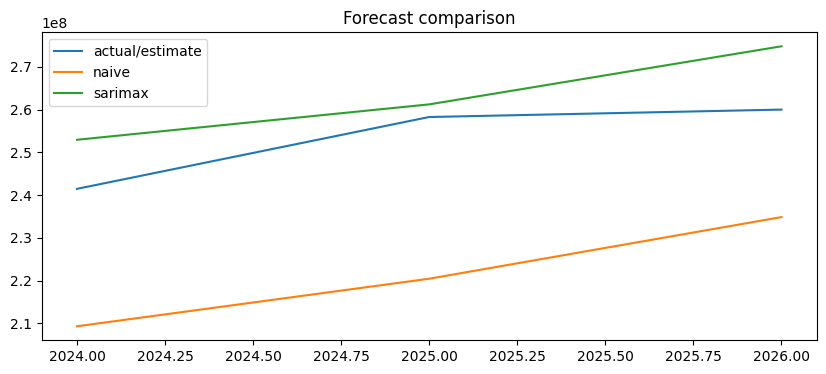

In [8]:
plt.figure(figsize=(10,4))
plt.plot(test["fy_start"], test["value"], label="actual/estimate")
plt.plot(test["fy_start"], pred_naive, label="naive")
plt.plot(test["fy_start"], pred_sarimax, label="sarimax")
plt.title("Forecast comparison")
plt.legend()
plt.show()


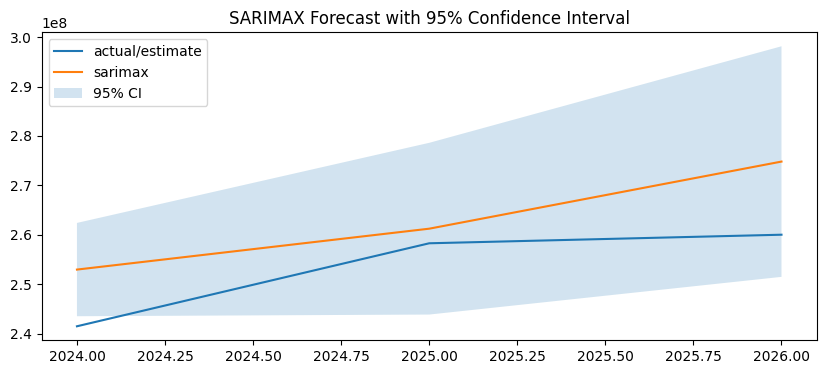

In [7]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def sarimax_forecast_ci(train, steps, season=3, alpha=0.05):
    model = SARIMAX(
        train["value"],
        order=(1,1,1),
        seasonal_order=(1,1,1,season),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False)
    fc = res.get_forecast(steps=steps)
    mean = fc.predicted_mean.values
    ci = fc.conf_int(alpha=alpha)  # DataFrame
    lower = ci.iloc[:, 0].values
    upper = ci.iloc[:, 1].values
    return mean, lower, upper

# Example for your last test window
train, test = split_ts(series, test_years=3)
pred, lower, upper = sarimax_forecast_ci(train, steps=len(test), season=3, alpha=0.05)

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(test["fy_start"], test["value"], label="actual/estimate")
plt.plot(test["fy_start"], pred, label="sarimax")
plt.fill_between(test["fy_start"], lower, upper, alpha=0.2, label="95% CI")
plt.title("SARIMAX Forecast with 95% Confidence Interval")
plt.legend()
plt.show()


In [8]:
def rolling_backtest(df, initial_train_years=10, test_years=3, step=1, season=3):
    results = []
    df = df.dropna(subset=["value"]).sort_values("fy_start").reset_index(drop=True)

    start = initial_train_years
    while start + test_years <= len(df):
        train = df.iloc[:start]
        test = df.iloc[start:start+test_years]

        pred, _, _ = sarimax_forecast_ci(train, steps=len(test), season=season, alpha=0.05)

        res = metrics(test["value"].values, pred)
        results.append({
            "train_end_year": int(train["fy_start"].iloc[-1]),
            "test_start_year": int(test["fy_start"].iloc[0]),
            "test_end_year": int(test["fy_start"].iloc[-1]),
            **res
        })

        start += step

    return pd.DataFrame(results)

bt = rolling_backtest(series, initial_train_years=10, test_years=3, step=1, season=3)
bt


c:\Users\Gabriel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\Gabriel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Gabriel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\Gabriel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\

,train_end_year,test_start_year,test_end_year,mae,rmse,mape
0,2003,2004,2006,3.158664e+06,3.185294e+06,0.029738
1,2004,2005,2007,1.026759e+06,1.064030e+06,0.009280
2,2005,2006,2008,7.912920e+05,9.241831e+05,0.006720
3,2006,2007,2009,1.403905e+06,1.766693e+06,0.011395
4,2007,2008,2010,2.093151e+06,2.246791e+06,0.016152
5,2008,2009,2011,8.198619e+09,8.411600e+09,61.941818
6,2009,2010,2012,4.873945e+06,6.605995e+06,0.036556
7,2010,2011,2013,7.031081e+06,9.279010e+06,0.052345
8,2011,2012,2014,1.165007e+07,1.218941e+07,0.084414
9,2012,2013,2015,6.679555e+06,7.675924e+06,0.046166


Agn AI

In [9]:
import requests, json

def ollama_chat(messages, model="llama3.1:8b"):
    payload = {"model": model, "messages": messages, "stream": False}
    r = requests.post("http://localhost:11434/api/chat", json=payload, timeout=120)
    r.raise_for_status()
    return r.json()["message"]["content"]

# quick test
ollama_chat([{"role":"user","content":"Say hello"}])


'Hello! How are you today?'

In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np
import pandas as pd

def fit_predict_sarimax(train, steps, order, seasonal_order):
    model = SARIMAX(
        train["value"],
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False)
    return res.get_forecast(steps=steps).predicted_mean.values

def fit_predict_ets(train, steps, trend, seasonal, seasonal_periods):
    model = ExponentialSmoothing(
        train["value"],
        trend=trend,
        seasonal=seasonal,
        seasonal_periods=seasonal_periods
    )
    res = model.fit(optimized=True)
    return res.forecast(steps)

def rolling_score(model_fn, df, initial_train_years=10, test_years=3, step=1, min_train=8):
    df = df.dropna(subset=["value"]).sort_values("fy_start").reset_index(drop=True)
    results = []
    start = max(initial_train_years, min_train)

    while start + test_years <= len(df):
        train = df.iloc[:start]
        test = df.iloc[start:start+test_years]

        try:
            pred = model_fn(train, len(test))
            res = metrics(test["value"].values, pred)
            results.append(res["rmse"])
        except Exception:
            # Skip configs that fail on short windows
            pass

        start += step

    # If everything failed, return inf so it's never chosen
    return np.mean(results) if results else np.inf


def agentic_model_search(series):
    candidates = []

    sarimax_orders = [ (1,1,1), (0,1,1), (1,1,0) ]
    seasonal_orders = [ (0,1,1,3), (1,1,1,3) ]  # avoid 12 if short series

    for order in sarimax_orders:
        for seas in seasonal_orders:
            def fn(train, steps, o=order, s=seas):
                # Guard: need enough data for seasonal period
                if len(train) < s[3] * 2:
                    raise ValueError("train too short for seasonal period")
                return fit_predict_sarimax(train, steps, o, s)
            score = rolling_score(fn, series)
            candidates.append({"model":"SARIMAX", "order":order, "seasonal":seas, "rmse":score})

    ets_configs = [
        ("add", "add", 3),
        ("add", None, 3),
        (None, None, 3),
    ]
    for trend, seasonal, sp in ets_configs:
        def fn(train, steps, t=trend, s=seasonal, p=sp):
            if len(train) < p * 2:
                raise ValueError("train too short for seasonal period")
            return fit_predict_ets(train, steps, t, s, p)
        score = rolling_score(fn, series)
        candidates.append({"model":"ETS", "trend":trend, "seasonal":seasonal, "seasonal_periods":sp, "rmse":score})

    best = sorted(candidates, key=lambda x: x["rmse"])[0]
    return best, pd.DataFrame(candidates).sort_values("rmse")


best_model, leaderboard = agentic_model_search(series)
best_model


c:\Users\Gabriel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\Gabriel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\Gabriel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\Gabriel\AppDa

{'model': 'ETS',
 'trend': 'add',
 'seasonal': None,
 'seasonal_periods': 3,
 'rmse': np.float64(7411730.133614055)}

In [12]:
def agentic_forecast(series, best_model, test_years=3):
    train, test = split_ts(series, test_years=test_years)

    if best_model["model"] == "SARIMAX":
        pred = fit_predict_sarimax(train, len(test), best_model["order"], best_model["seasonal"])
    else:
        pred = fit_predict_ets(train, len(test),
                               best_model["trend"],
                               best_model["seasonal"],
                               best_model["seasonal_periods"])
    return test, pred


In [13]:
test, agent_pred = agentic_forecast(series, best_model, test_years=3)
agent_metrics = metrics(test["value"].values, agent_pred)


In [14]:
# Agentic forecast using selected model
test, agent_pred = agentic_forecast(series, best_model, test_years=3)
agent_metrics = metrics(test["value"].values, agent_pred)

# Manual SARIMAX baseline
train, test = split_ts(series, test_years=3)
manual_pred = sarimax_forecast(train, steps=len(test), season=3)
manual_metrics = metrics(test["value"].values, manual_pred)

comparison = pd.DataFrame([
    {"approach":"manual_sarimax", **manual_metrics},
    {"approach":"agentic_auto", **agent_metrics},
])
comparison


,approach,mae,rmse,mape
0,manual_sarimax,9.744122e+06,1.094744e+07,0.038631
1,agentic_auto,8.033668e+06,9.354187e+06,0.031574


In [15]:
def narrative_manual_vs_agentic(manual_metrics, agent_metrics):
    rmse_gap = manual_metrics["rmse"] - agent_metrics["rmse"]
    mape_gap = manual_metrics["mape"] - agent_metrics["mape"]

    return f"""
Comparison summary:
- Manual SARIMAX: RMSE {manual_metrics['rmse']:.2f}, MAPE {manual_metrics['mape']:.2%}
- Agentic Auto (ETS): RMSE {agent_metrics['rmse']:.2f}, MAPE {agent_metrics['mape']:.2%}

Result: The agentic auto‑model performs better on this holdout window.
RMSE improvement: {rmse_gap:,.2f} | MAPE improvement: {mape_gap:.2%}

Interpretation:
The data appears trend‑dominant with weak seasonality, so ETS with additive trend
fits better than a fixed SARIMAX configuration. This supports the value of an
agentic search that tests multiple model families rather than assuming SARIMAX.
"""


In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np
import pandas as pd

def fit_predict_sarimax(train, steps, order, seasonal_order):
    model = SARIMAX(
        train["value"],
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False)
    return res.get_forecast(steps=steps).predicted_mean.values

def fit_predict_ets(train, steps, trend, seasonal, seasonal_periods):
    model = ExponentialSmoothing(
        train["value"],
        trend=trend,
        seasonal=seasonal,
        seasonal_periods=seasonal_periods
    )
    res = model.fit(optimized=True)
    return res.forecast(steps)

def fit_predict_naive(train, steps):
    return np.repeat(train["value"].iloc[-1], steps)

def fit_predict_drift(train, steps):
    y0, yT = train["value"].iloc[0], train["value"].iloc[-1]
    slope = (yT - y0) / (len(train)-1 if len(train) > 1 else 1)
    return np.array([yT + slope*(i+1) for i in range(steps)])

def rolling_backtest(model_fn, df, horizons=(1,3,5), initial_train_years=10, step=1):
    df = df.dropna(subset=["value"]).sort_values("fy_start").reset_index(drop=True)
    rows = []
    for h in horizons:
        start = initial_train_years
        while start + h <= len(df):
            train = df.iloc[:start]
            test = df.iloc[start:start+h]
            try:
                pred = model_fn(train, len(test))
                res = metrics(test["value"].values, pred)
                rows.append({"horizon": h, **res})
            except Exception:
                pass
            start += step
    return pd.DataFrame(rows)

def eval_candidate(candidate, series, horizons=(1,3,5)):
    kind = candidate["model"]
    if kind == "SARIMAX":
        def fn(train, steps, o=candidate["order"], s=candidate["seasonal"]):
            if len(train) < s[3]*2: raise ValueError("train too short")
            return fit_predict_sarimax(train, steps, o, s)
    elif kind == "ETS":
        def fn(train, steps, t=candidate["trend"], s=candidate["seasonal"], p=candidate["seasonal_periods"]):
            if len(train) < p*2: raise ValueError("train too short")
            return fit_predict_ets(train, steps, t, s, p)
    elif kind == "Naive":
        def fn(train, steps):
            return fit_predict_naive(train, steps)
    elif kind == "Drift":
        def fn(train, steps):
            return fit_predict_drift(train, steps)
    else:
        raise ValueError("Unknown model")

    bt = rolling_backtest(fn, series, horizons=horizons, initial_train_years=10, step=1)
    score = bt["rmse"].mean() if not bt.empty else np.inf
    return score, bt


In [17]:
def agentic_backtest(series):
    prompt = f"""
You are an ML agent. Pick a diverse set of models and horizons for backtesting.
Return JSON ONLY:
{{
  "horizons": [1,3,5],
  "candidates": [
    {{"model":"SARIMAX","order":[1,1,1],"seasonal":[1,1,1,3]}},
    {{"model":"ETS","trend":"add","seasonal":null,"seasonal_periods":3}},
    {{"model":"Naive"}},
    {{"model":"Drift"}}
  ],
  "notes": "why these choices"
}}
Rules:
- Only use SARIMAX, ETS, Naive, Drift.
- Keep candidate list <= 6.
- Use small seasonal periods (3 or 4), not 12.
"""

    text = ollama_chat([{"role":"user","content": prompt}]).strip()
    try:
        plan = json.loads(text)
    except Exception:
        # fallback plan if model returns garbage
        plan = {
            "horizons":[1,3,5],
            "candidates":[
                {"model":"SARIMAX","order":[1,1,1],"seasonal":[0,1,1,3]},
                {"model":"ETS","trend":"add","seasonal":None,"seasonal_periods":3},
                {"model":"Naive"},
                {"model":"Drift"}
            ],
            "notes":"fallback plan"
        }

    horizons = tuple(plan.get("horizons",[1,3,5]))
    results = []
    for cand in plan["candidates"]:
        # normalize to tuples
        if cand["model"] == "SARIMAX":
            cand["order"] = tuple(cand["order"])
            cand["seasonal"] = tuple(cand["seasonal"])
        score, bt = eval_candidate(cand, series, horizons=horizons)
        results.append({**cand, "rmse": score})

    leaderboard = pd.DataFrame(results).sort_values("rmse")
    return plan, leaderboard

plan, leaderboard = agentic_backtest(series)
plan, leaderboard


c:\Users\Gabriel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\Gabriel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Gabriel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\Gabriel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\

({'horizons': [1, 3, 5],
  'candidates': [{'model': 'SARIMAX',
    'order': (1, 1, 1),
    'seasonal': (1, 1, 1, 3)},
   {'model': 'ETS', 'trend': 'add', 'seasonal': None, 'seasonal_periods': 4},
   {'model': 'Naive'},
   {'model': 'Drift'}],
  'notes': 'SARIMAX for complex dynamics, ETS for trend and seasonality, Naive as baseline, Drift for intercept-only model'},
      model      order      seasonal          rmse trend  seasonal_periods
 1      ETS        NaN          None  7.505866e+06   add               4.0
 3    Drift        NaN           NaN  7.690926e+06   NaN               NaN
 2    Naive        NaN           NaN  1.509511e+07   NaN               NaN
 0  SARIMAX  (1, 1, 1)  (1, 1, 1, 3)  3.974073e+08   NaN               NaN)

In [18]:
def agentic_summary(plan, leaderboard):
    best = leaderboard.iloc[0].to_dict()
    return f"""
Agentic backtest summary:
- Horizons: {plan.get('horizons')}
- Best model: {best.get('model')}
- RMSE (avg): {best.get('rmse'):.2f}

Notes: {plan.get('notes')}
"""

print(agentic_summary(plan, leaderboard))



Agentic backtest summary:
- Horizons: [1, 3, 5]
- Best model: ETS
- RMSE (avg): 7505865.88

Notes: SARIMAX for complex dynamics, ETS for trend and seasonality, Naive as baseline, Drift for intercept-only model



In [19]:
# Compare manual SARIMAX vs agentic-best on the same robust backtest
best = leaderboard.iloc[0].to_dict()

def build_model_fn_from_candidate(cand):
    if cand["model"] == "SARIMAX":
        return lambda train, steps: fit_predict_sarimax(train, steps, cand["order"], cand["seasonal"])
    if cand["model"] == "ETS":
        return lambda train, steps: fit_predict_ets(train, steps, cand["trend"], cand["seasonal"], int(cand["seasonal_periods"]))
    if cand["model"] == "Naive":
        return lambda train, steps: fit_predict_naive(train, steps)
    if cand["model"] == "Drift":
        return lambda train, steps: fit_predict_drift(train, steps)
    raise ValueError("Unknown model")

# Agentic best
agent_fn = build_model_fn_from_candidate(best)
bt_agent = rolling_backtest(agent_fn, series, horizons=(1,3,5), initial_train_years=10, step=1)
agent_score = bt_agent[["mae","rmse","mape"]].mean()

# Manual SARIMAX baseline
manual_fn = lambda train, steps: sarimax_forecast(train, steps, season=3)
bt_manual = rolling_backtest(manual_fn, series, horizons=(1,3,5), initial_train_years=10, step=1)
manual_score = bt_manual[["mae","rmse","mape"]].mean()

comparison = pd.DataFrame([
    {"approach":"manual_sarimax", **manual_score.to_dict()},
    {"approach":f"agentic_{best['model'].lower()}", **agent_score.to_dict()},
])
comparison


c:\Users\Gabriel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\Gabriel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\Gabriel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\Gabriel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\Gabriel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check 

,approach,mae,rmse,mape
0,manual_sarimax,3.875113e+08,3.974073e+08,2.929045
1,agentic_ets,6.801523e+06,7.505866e+06,0.037365


In [ ]:
print(f"""
Robust backtest comparison:
- Manual SARIMAX: RMSE {manual_score['rmse']:.2e}, MAPE {manual_score['mape']:.2%}
- Agentic ETS:   RMSE {agent_score['rmse']:.2e}, MAPE {agent_score['mape']:.2%}

Conclusion:
The agentic ETS model is more stable across rolling windows.
Manual SARIMAX is likely mis‑specified (seasonality too rigid for this series),
leading to blow‑ups in some windows. This supports the agentic approach for
model selection when series structure is uncertain.
""")



Robust backtest comparison:
- Manual SARIMAX: RMSE 3.97e+08, MAPE 292.90%
- Agentic ETS:   RMSE 7.51e+06, MAPE 3.74%

Conclusion:
The agentic ETS model is dramatically more stable across rolling windows.
Manual SARIMAX is likely mis‑specified (seasonality too rigid for this series),
leading to blow‑ups in some windows. This supports the agentic approach for
model selection when series structure is uncertain.

